In [25]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pickle
import seaborn as sns
import sys

sys.path.append("../../bosporus-package/")

In [3]:
from bosporus.distances import *
from bosporus.centrality_measures import compute_centrality_measures

In [4]:
G = nx.Graph(pickle.load(open('geo_data/street_network.pickle', 'rb')))

In [5]:
relabel = {n: i for i, n in enumerate(G.nodes)}

In [7]:
G = nx.relabel_nodes(G, relabel)

In [9]:
pixel_pos = np.load("geo_data/node_pixels.npy")

In [10]:
ocean = np.load("geo_data/ocean.npy")
mask = np.load("geo_data/national_parks.npy")

In [11]:
cities = np.load("geo_data/city_pixels.npy")

In [12]:
pixel_pos_dict = {n: pixel_pos[i][::-1] for i,n in enumerate(G.nodes)}

In [13]:
for (u, v) in G.edges:
    if u == v:
        G.remove_edge(u, v)

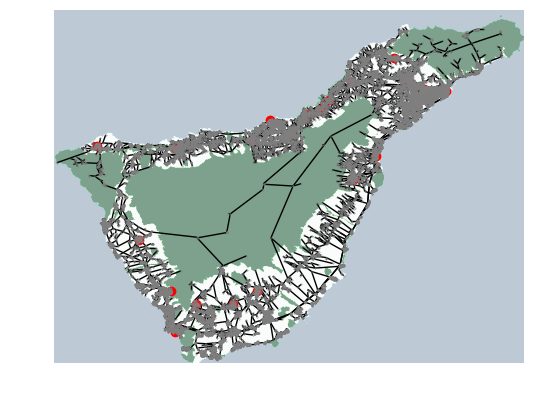

In [14]:
f, ax = plt.subplots(1, figsize=(8,5))
nx.draw(G, pos=pixel_pos_dict, node_size=0.1, ax=ax, node_color="grey")
ax.imshow(ocean, alpha=0.5, cmap="Blues")
ax.imshow(mask, alpha=0.5, cmap="Greens")
plt.scatter(cities[:,1], cities[:,0], color="red")

In [15]:
df = pd.DataFrame(pixel_pos_dict).T
df.columns = ["x", "y"]

In [40]:
df["distance_to_ocean"] = distance_to_mask(np.array(list(pixel_pos_dict.values())), ocean).values
df["distance_to_national_park"] = distance_to_mask(np.array(list(pixel_pos_dict.values())), mask).values
df["distance_to_city"] = distance_to_pointset(np.array(list(pixel_pos_dict.values())), cities).values
df["distance_to_ocean_or_national_park"] = distance_to_mask(np.array(list(pixel_pos_dict.values())), np.logical_or(ocean, mask)).values

In [41]:
centralities = compute_centrality_measures(G.edges(), len(df))

In [42]:
result_df = pd.concat([df, pd.DataFrame(centralities)], axis=1)

<Axes: xlabel='distance_to_city', ylabel='closeness'>

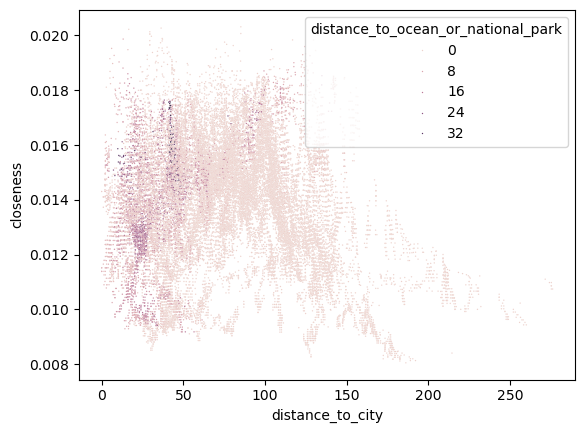

In [46]:
sns.scatterplot(result_df, x="distance_to_city", hue="distance_to_ocean_or_national_park", y="closeness", s=1)

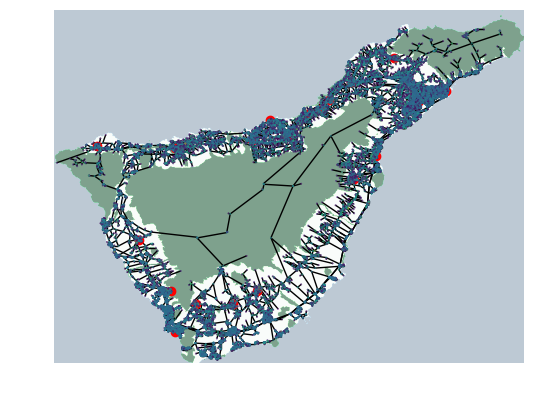

In [47]:
f, ax = plt.subplots(1, figsize=(8,5))
nx.draw(G, pos=pixel_pos_dict, node_size=0.1, ax=ax, node_color=result_df["pagerank"])
ax.imshow(ocean, alpha=0.5, cmap="Blues")
ax.imshow(mask, alpha=0.5, cmap="Greens")
plt.scatter(cities[:,1], cities[:,0], color="red")

In [48]:
result_df["pagerank"]

0        0.000031
1        0.000031
2        0.000031
3        0.000033
4        0.000031
           ...   
32103    0.000032
32104    0.000032
32105    0.000032
32106    0.000046
32107    0.000018
Name: pagerank, Length: 32108, dtype: float64